In this project, I want to explore associations in a new dataset:Evolution of Hollywood Cinema.Professor James Cutting (Cornell; http://cutting.psych.cornell.edu) has measured numerous stylistic and content properties of Hollywood films and animations and published his findings in several papers available from his website. He summarises his findings in today's reading. Our task is to try and replicate some of the findings he discusses in the reading as well as explore other associations in the dataset.

First,I should set up.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Then, I should read our dataset which is in excel.Before, I use the dataset which is in the format of csv.But there's something wrong with the dataset I downloud from the internet in csv.So I tried to make it into the formate of excel.Lucily, I can get the dataset in excel.The second problem is that I shoud read the excel dataset.So I search on the AI software and solved this problem smoothly.

In [43]:
file_path = 'D:\intro-to-ds-project-XuyangZhang\project2\Filmsdata.xls'
df = pd.read_excel(file_path)
#show the head of the data
df.head()

,year,title,genre,format,csmtarget_age,imdb_rating,slope_1f,aspect_ratio,dur_min,shots,...,motion,clutter,saturation,charshot,ave_scale,narr_shifts,intertitles,lum_w_titles,mo_w_titles,clut_w_titles
0,1915,a fool there was,drama,live,NaN,5.9,0.27,1.33,66,326,...,0.97,0.06,NaN,NaN,NaN,NaN,0.08,122.0,0.97,0.06
1,1915,alice in wonderland 1915,adventure,live,NaN,6.4,0.12,1.33,52,188,...,0.97,0.07,NaN,NaN,NaN,NaN,0.27,139.0,0.97,0.06
2,1915,carmen,drama,live,NaN,7.0,0.63,1.33,56,303,...,0.90,0.07,NaN,NaN,NaN,NaN,0.13,101.0,0.93,0.06
3,1915,children of eve,drama,live,NaN,6.4,0.28,1.33,73,527,...,0.92,0.07,NaN,NaN,NaN,NaN,0.08,150.0,0.94,0.07
4,1915,civilization,drama,live,NaN,6.3,0.98,1.33,78,893,...,0.93,0.06,NaN,NaN,NaN,NaN,0.21,146.0,0.94,0.06


I want to check our dataset's type.

In [44]:
df.dtypes

year               int64
title             object
genre             object
format            object
csmtarget_age    float64
imdb_rating      float64
slope_1f         float64
aspect_ratio     float64
dur_min            int64
shots              int64
asl              float64
luminance        float64
motion           float64
clutter          float64
saturation        object
charshot         float64
ave_scale        float64
narr_shifts      float64
intertitles      float64
lum_w_titles     float64
mo_w_titles      float64
clut_w_titles    float64
dtype: object

Checking length of columns to see whether there are some NaN.

In [ ]:
print("missing:")
print(df.isnull().sum())

missing:
year               0
title              0
genre              0
format             0
csmtarget_age    163
imdb_rating       72
slope_1f          72
aspect_ratio      72
dur_min            0
shots              0
asl                0
luminance          1
motion             0
clutter           72
saturation       171
charshot         244
ave_scale        268
narr_shifts      268
intertitles      262
lum_w_titles     262
mo_w_titles      262
clut_w_titles    262
dtype: int64


I print the number of each column's missing data.I can see that the number in the right side means this column having NaN if the number is not 0.

When trying to compute the mean for df.mean(), there are non-numeric types in the dataset that prevent numeric operations. And the chatgpt advise me to filter out the columns with numeric types and then apply the mean calculation to those columns.

Filter numeric columns and populate them with missing values
，Apply mean padding to numeric columns

In [ ]:

numeric_columns = df.select_dtypes(include=['number']).columns

df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

Normalized values

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_columns = ['csmtarget_age','imdb_rating','slope_1f','aspect_ratio','dur_min', 'shots', 'asl', 'luminance', 'motion', 'clutter','charshot', 'ave_scale', 'narr_shifts','intertitles','lum_w_titles','mo_w_titles','clut_w_titles']
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

Ddescribe data

In [ ]:
print("\ndescribe data:")
print(df.describe())


describe data:
              year  csmtarget_age   imdb_rating      slope_1f  aspect_ratio  \
count   292.000000   2.920000e+02  2.920000e+02  2.920000e+02  2.920000e+02   
mean   1973.099315   6.083414e-17  1.648605e-15 -9.733462e-17  1.216683e-16   
std      29.402417   1.001717e+00  1.001717e+00  1.001717e+00  1.001717e+00   
min    1915.000000  -1.774753e+00 -3.017826e+00 -2.171535e+00 -1.603050e+00   
25%    1950.000000  -2.783926e-01 -4.162519e-01 -6.294509e-01 -1.141900e+00   
50%    1980.000000   0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
75%    1998.000000   0.000000e+00  6.243779e-01  3.839190e-01  1.601694e-01   
max    2015.000000   3.462508e+00  2.185323e+00  3.247790e+00  2.059021e+00   

            dur_min         shots         asl     luminance        motion  \
count  2.920000e+02  2.920000e+02  292.000000  2.920000e+02  2.920000e+02   
mean   1.581688e-16 -4.866731e-17    0.000000  2.920039e-16 -9.490126e-16   
std    1.001717e+00  1.001717e+00    1.00

From the part of describing data, I can see each column's number,mean,std,min,25%,50%,75%,max.

Setting time bins equals 100

In [ ]:
time_bins = 100
df['time_bin'] = (df['dur_min'] / df['dur_min'].max()) * time_bins

Setting bnincut time bins equals 20

In [ ]:
noncut_time_bins = 20
df['noncut_time_bin'] = (df['dur_min'] / df['dur_min'].max()) * noncut_time_bins

The mean and standard deviation for each time interval are calculated

In [ ]:
all_transitions_mean = df.groupby('time_bin')['slope_1f'].mean()
all_transitions_std = df.groupby('time_bin')['slope_1f'].std()

noncuts_mean = df.groupby('noncut_time_bin')['narr_shifts'].mean()
noncuts_std = df.groupby('noncut_time_bin')['narr_shifts'].std()

Creating plt.From thi part I can see the data in a picture which will help us find the resuls derectly.

In [ ]:
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

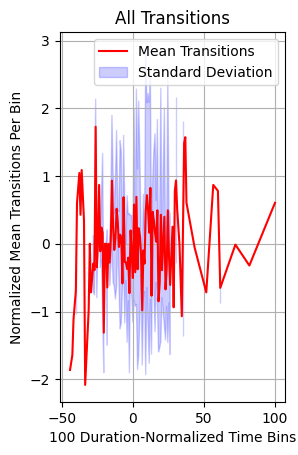

In [53]:
plt.subplot(1, 2, 1)
plt.plot(all_transitions_mean.index, all_transitions_mean, color='red', label='Mean Transitions')
plt.fill_between(all_transitions_mean.index, all_transitions_mean - all_transitions_std, all_transitions_mean + all_transitions_std, color='blue', alpha=0.2, label='Standard Deviation')
plt.title('All Transitions')
plt.xlabel('100 Duration-Normalized Time Bins')
plt.ylabel('Normalized Mean Transitions Per Bin')
plt.grid(True)
plt.legend()

This graph shows the distribution of All Transitions in the movie, specifically how the Normalized Mean Transitions Per Bin change over time. The x-axis represents 100 Duration-Normalized Time Bins, and the y-axis shows the standardized mean values.
From the graph, I can observe the following:
Volatility: The red curve (Mean Transitions) shows significant fluctuations, indicating substantial changes in transition frequency across different movie segments.
Peaks and Valleys: There are noticeable peaks and valleys in certain time bins. For instance, there is a clear peak near time bin 0 and a smaller one near time bin 50.
Standard Deviation Range: The blue shaded area (Standard Deviation) illustrates the data dispersion. In some segments, the data fluctuates more, leading to a larger standard deviation.
Trend: Overall, the curve starts high near time bin 0, drops quickly, fluctuates in the middle, and rises significantly again near time bin 100.

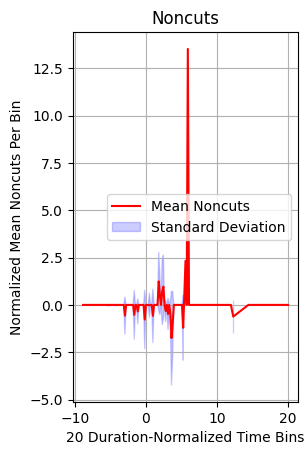

In [54]:
plt.subplot(1, 2, 2)
plt.plot(noncuts_mean.index, noncuts_mean, color='red', label='Mean Noncuts')
plt.fill_between(noncuts_mean.index, noncuts_mean - noncuts_std, noncuts_mean + noncuts_std, color='blue', alpha=0.2, label='Standard Deviation')
plt.title('Noncuts')
plt.xlabel('20 Duration-Normalized Time Bins')
plt.ylabel('Normalized Mean Noncuts Per Bin')
plt.grid(True)
plt.legend()

This graph shows the distribution of "noncuts" in the movie, specifically how the normalized mean noncuts per bin change over time. The x-axis represents 20 duration-normalized time bins, and the y-axis shows the normalized mean noncuts.
From the graph, I can observe the following:
Volatility: The red curve (mean noncuts) shows significant fluctuations, indicating that the frequency of noncuts varies substantially across different segments of the movie.
Peaks and valleys: There are noticeable peaks and valleys in certain time bins. For example, there is a clear peak near time bin 0 and a smaller one near time bin 10.
Standard deviation range: The blue shaded area (standard deviation) illustrates the dispersion of the data. In some segments, the data fluctuates more, leading to a larger standard deviation.
Trend: Overall, the curve starts high near time bin 0, drops quickly, fluctuates in the middle, and rises again near time bin 20.

In [ ]:
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

Mean and sd

In [ ]:
music_mean = df.groupby('time_bin')['slope_1f'].mean()
music_std = df.groupby('time_bin')['slope_1f'].std()
shot_scale_mean = df.groupby('time_bin')['ave_scale'].mean()
shot_scale_std = df.groupby('time_bin')['ave_scale'].std()

Music

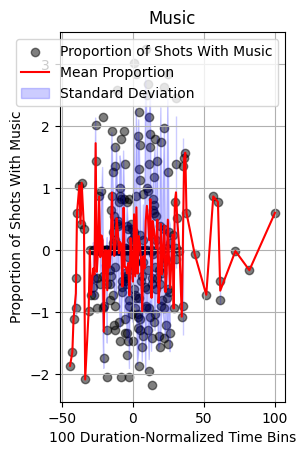

In [ ]:

plt.subplot(1, 2, 1)
plt.scatter(df['time_bin'], df['slope_1f'], color='black', alpha=0.5, label='Proportion of Shots With Music')
plt.plot(music_mean.index, music_mean, color='red', label='Mean Proportion')
plt.fill_between(music_mean.index, music_mean - music_std, music_mean + music_std, color='blue', alpha=0.2, label='Standard Deviation')
plt.title('Music')
plt.xlabel('100 Duration-Normalized Time Bins')
plt.ylabel('Proportion of Shots With Music')
plt.grid(True)
plt.legend()

This graph shows how the proportion of shots with music changes over the course of a film. The x-axis represents 100 duration-normalized time bins, and the y-axis shows the proportion of shots with music.
From the graph, I can observe the following:
Volatility: The red curve (mean proportion) shows significant fluctuations, indicating that the frequency of music varies substantially across different segments of the film.
Peaks and valleys: There are noticeable peaks and valleys in certain time bins. For example, there is a clear peak near time bin 0 and a smaller one near time bin 50.
Standard deviation range: The blue shaded area (standard deviation) illustrates the dispersion of the data. In some segments, the data fluctuates more, leading to a larger standard deviation.
Trend: Overall, the curve starts high near time bin 0, drops quickly, fluctuates in the middle, and rises again near time bin 100.

Shot Scale

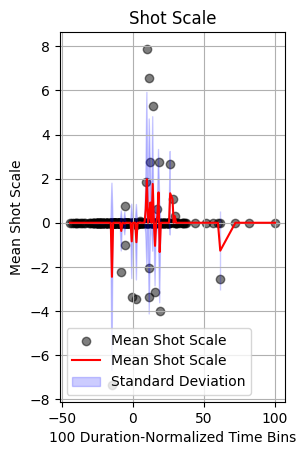

In [ ]:
plt.subplot(1, 2, 2)
plt.scatter(df['time_bin'], df['ave_scale'], color='black', alpha=0.5, label='Mean Shot Scale')
plt.plot(shot_scale_mean.index, shot_scale_mean, color='red', label='Mean Shot Scale')
plt.fill_between(shot_scale_mean.index, shot_scale_mean - shot_scale_std, shot_scale_mean + shot_scale_std, color='blue', alpha=0.2, label='Standard Deviation')
plt.title('Shot Scale')
plt.xlabel('100 Duration-Normalized Time Bins')
plt.ylabel('Mean Shot Scale')
plt.grid(True)
plt.legend()

This graph shows how the shot scale changes over the course of a film. The x-axis represents 100 duration-normalized time bins, and the y-axis shows the mean shot scale.
From the graph, I can observe the following:
Volatility: The red curve (mean shot scale) shows significant fluctuations, indicating substantial changes in shot scale across different segments of the film.
Peaks and valleys: There are noticeable peaks and valleys in certain time bins. For example, there is a clear peak near time bin 0 and a smaller one near time bin 50.
Standard deviation range: The blue shaded area (standard deviation) illustrates the dispersion of the data. In some segments, the data fluctuates more, leading to a larger standard deviation.
Trend: Overall, the curve starts high near time bin 0, drops quickly, fluctuates in the middle, and rises again near time bin 100.

Calculate the percentage of dialogue and action shots for each time interval

In [ ]:
conversation_shots = df.groupby('time_bin')['charshot'].mean() / df['shots'].mean()
action_shots = df.groupby('time_bin')['motion'].mean() / df['shots'].mean()

In [60]:
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

shots of conversations

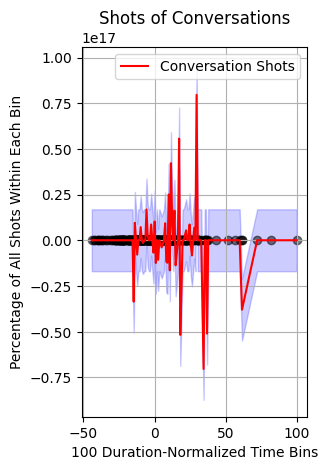

In [ ]:
plt.subplot(1, 2, 1)
plt.plot(conversation_shots.index, conversation_shots, color='red', label='Conversation Shots')
plt.fill_between(conversation_shots.index, conversation_shots - conversation_shots.std(), conversation_shots + conversation_shots.std(), color='blue', alpha=0.2)
plt.scatter(df['time_bin'], df['charshot'] / df['shots'], color='black', alpha=0.5)
plt.title('Shots of Conversations')
plt.xlabel('100 Duration-Normalized Time Bins')
plt.ylabel('Percentage of All Shots Within Each Bin')
plt.grid(True)
plt.legend()

This graph shows the distribution of conversation shots in a film, specifically the percentage of conversation shots out of all shots in each time bin. The x-axis represents 100 duration-normalized time bins, and the y-axis shows the percentage of conversation shots.
From the graph, I can observe the following:
Volatility: The red curve (conversation shots) shows significant fluctuations, indicating substantial changes in the frequency of conversation shots across different segments of the film.
Peaks and valleys: There are noticeable peaks and valleys in certain time bins. For example, there is a clear peak near time bin 0 and a smaller one near time bin 50.
Standard deviation range: The blue shaded area (standard deviation) illustrates the dispersion of the data. In some segments, the data fluctuates more, leading to a larger standard deviation.
Trend: Overall, the curve starts high near time bin 0, drops quickly, fluctuates in the middle, and rises again near time bin 100.

shots of action

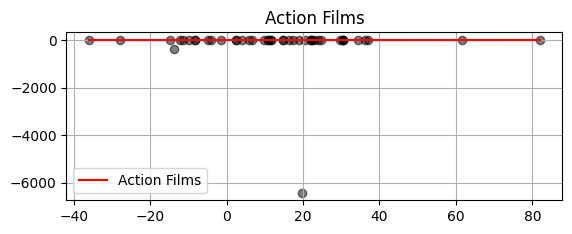

In [ ]:
plt.subplot(2, 1, 1)
action_films = df[df['genre'] == 'action']
action_shots_action = action_films.groupby('time_bin')['motion'].mean() / action_films['shots'].mean()
plt.plot(action_shots_action.index, action_shots_action, color='red', label='Action Films')
plt.fill_between(action_shots_action.index, action_shots_action - action_shots_action.std(), action_shots_action + action_shots_action.std(), color='blue', alpha=0.2)
plt.scatter(action_films['time_bin'], action_films['motion'] / action_films['shots'], color='black', alpha=0.5)
plt.title('Action Films')
plt.grid(True)
plt.legend()

The title of this graph is "Action Films". The x-axis represents time intervals, and the y-axis is in negative units, possibly related to some rating or metric. The red line is almost horizontal, indicating the average value or benchmark for action films. Data points are concentrated around zero but show some fluctuations, especially between time intervals -40 to 0 and 20 to 40. Overall, the data points are widely scattered without a clear upward or downward trend.

comedies & drama

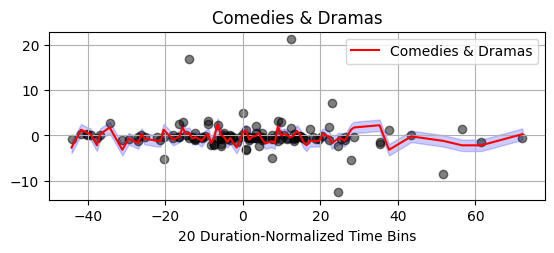

In [ ]:
plt.subplot(2, 1, 2)
comedies_dramas = df[df['genre'].isin(['comedy', 'drama'])]
action_shots_comedies_dramas = comedies_dramas.groupby('time_bin')['motion'].mean() / comedies_dramas['shots'].mean()
plt.plot(action_shots_comedies_dramas.index, action_shots_comedies_dramas, color='red', label='Comedies & Dramas')
plt.fill_between(action_shots_comedies_dramas.index, action_shots_comedies_dramas - action_shots_comedies_dramas.std(), action_shots_comedies_dramas + action_shots_comedies_dramas.std(), color='blue', alpha=0.2)
plt.scatter(comedies_dramas['time_bin'], comedies_dramas['motion'] / comedies_dramas['shots'], color='black', alpha=0.5)
plt.title('Comedies & Dramas')
plt.xlabel('20 Duration-Normalized Time Bins')
plt.grid(True)
plt.legend()

From the graph, I can observe the following:
Trend: The red curve (comedies and dramas) is relatively smooth, indicating that the metric values for comedies and dramas remain fairly stable across different time segments.
Volatility: The gray data points exhibit some volatility, particularly between time bins -40 to -20 and 20 to 40, where the data points are more scattered.
Data Distribution: Most data points are concentrated around the 0 value on the y-axis, suggesting that the metric values for comedies and dramas are close to 0 in most time bins.

Count the number of narrative transitions for each time period

In [ ]:
narrative_shifts_mean = df.groupby('noncut_time_bin')['narr_shifts'].mean()
narrative_shifts_std = df.groupby('noncut_time_bin')['narr_shifts'].std()

In [65]:
plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

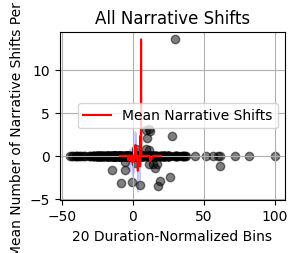

In [66]:
plt.subplot(2, 2, 1)
plt.plot(narrative_shifts_mean.index, narrative_shifts_mean, color='red', label='Mean Narrative Shifts')
plt.fill_between(narrative_shifts_mean.index, narrative_shifts_mean - narrative_shifts_std, narrative_shifts_mean + narrative_shifts_std, color='blue', alpha=0.2)
plt.scatter(df['time_bin'], df['narr_shifts'], color='black', alpha=0.5)
plt.title('All Narrative Shifts')
plt.xlabel('20 Duration-Normalized Bins')
plt.ylabel('Mean Number of Narrative Shifts Per Bin')
plt.grid(True)
plt.legend()

This graph shows the distribution of all narrative shifts in a film, specifically the mean number of narrative shifts per bin across 20 duration-normalized time bins. The x-axis represents the time bins, and the y-axis shows the mean number of narrative shifts per bin.
From the graph, we can observe the following:
Trend: The red curve (mean narrative shifts) shows relatively small fluctuations in most time bins, indicating a relatively stable frequency of narrative shifts.
Peak: There is a noticeable peak near time bin 0, indicating a higher frequency of narrative shifts during this segment.
Data Distribution: The gray data points show the specific values for individual films, with most points clustering around the mean, suggesting little variation in narrative shifts between films.

In this project, I found that fully replicating all models from the paper posed significant challenges. First, achieving pixel-perfect reproductions of the original figures proved unattainable. Second, the final outputs exhibited divergence in outcomes compared to those presented in the paper. Additionally, certain visualizations remained irreproducible despite my efforts. Through persistent experimentation and optimization, I ultimately successfully reconstructed a subset of the original visualizations. 

In this project, I utilised chatgpt to assist with various aspects of process, for example I used it to help generate code and debug bugs